# MobileNetV2 fine-tuned для классификации Cats vs Dogs

Отдельный ноутбук: используется тот же датасет `cats-and-dogs-mini-dataset`, что и в основной работе.

Что делает ноутбук:
1. Загружает изображения кошек и собак.
2. Делит данные на train/validation/test.
3. Создает модель MobileNetV2 с предобученными весами ImageNet.
4. Сначала обучает только новую классификационную голову.
5. Затем размораживает последние слои MobileNetV2 и выполняет fine-tuning.
6. Считает Accuracy, Precision, Recall, F1, confusion matrix.
7. Добавляет кнопку загрузки собственного изображения для проверки: кошка или собака.

## 1. Импорты и настройки

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 10
CLASS_NAMES = ['Cat', 'Dog']

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 2. Загрузка той же базы данных

In [3]:
def find_dataset_path():
    possible_paths = [
        '/kaggle/input/cats-and-dogs-mini-dataset',
        './cats-and-dogs-mini-dataset',
        '/mnt/data/cats-and-dogs-mini-dataset',
    ]
    for p in possible_paths:
        if os.path.isdir(os.path.join(p, 'cats_set')) and os.path.isdir(os.path.join(p, 'dogs_set')):
            return p

    try:
        import kagglehub
        path = kagglehub.dataset_download('aleemaparakatta/cats-and-dogs-mini-dataset')
        return path
    except Exception as e:
        raise FileNotFoundError(
            'Не удалось найти или скачать датасет. Укажите base_path вручную.'
        ) from e

base_path = find_dataset_path()
print('Path to dataset:', base_path)

for root, dirs, files in os.walk(base_path):
    if root.count(os.sep) - base_path.count(os.sep) <= 1:
        print(root, '| dirs:', dirs, '| files:', len(files))

Using Colab cache for faster access to the 'cats-and-dogs-mini-dataset' dataset.
Path to dataset: /kaggle/input/cats-and-dogs-mini-dataset
/kaggle/input/cats-and-dogs-mini-dataset | dirs: ['dogs_set', 'cats_set'] | files: 0
/kaggle/input/cats-and-dogs-mini-dataset/dogs_set | dirs: [] | files: 500
/kaggle/input/cats-and-dogs-mini-dataset/cats_set | dirs: [] | files: 500


In [4]:
def load_images(base_path, img_size=128):
    X, y = [], []
    classes = {'cats_set': 0, 'dogs_set': 1}

    for cls_name, label in classes.items():
        folder = os.path.join(base_path, cls_name)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype('float32') / 255.0
            X.append(img)
            y.append(label)

    return np.array(X, dtype='float32'), np.array(y, dtype='int32')

X, y = load_images(base_path, IMG_SIZE)
print('X:', X.shape, 'y:', y.shape)
print('Class balance:', dict(zip(*np.unique(y, return_counts=True))))

X: (1000, 128, 128, 3) y: (1000,)
Class balance: {np.int32(0): np.int64(500), np.int32(1): np.int64(500)}


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (640, 128, 128, 3) (640,)
Val:   (160, 128, 128, 3) (160,)
Test:  (200, 128, 128, 3) (200,)


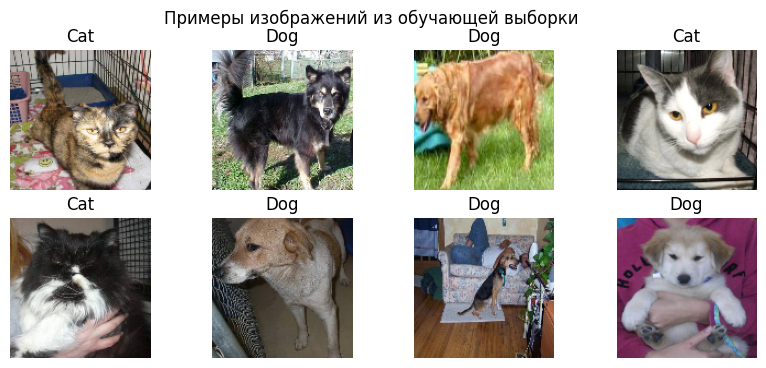

In [6]:
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis('off')
plt.suptitle('Примеры изображений из обучающей выборки')
plt.show()

## 3. Вспомогательные функции

In [7]:
results = []

def plot_history(history, title):
    hist = history.history

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist['loss'], label='train loss')
    plt.plot(hist['val_loss'], label='val loss')
    plt.title(title + ': loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['accuracy'], label='train accuracy')
    plt.plot(hist['val_accuracy'], label='val accuracy')
    plt.title(title + ': accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()


def evaluate_binary_model(model, X_test, y_test, model_name, train_time=None, notes=''):
    start_pred = time.time()
    y_prob = model.predict(X_test, verbose=0).ravel()
    pred_time = time.time() - start_pred

    y_pred = (y_prob >= 0.5).astype(int)

    row = {
        'Модель': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Параметры': model.count_params(),
        'Время обучения, сек': train_time,
        'Время предсказания test, сек': pred_time,
        'Комментарий': notes
    }
    results.append(row)

    print(model_name)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    plt.imshow(cm)
    plt.title(f'Confusion matrix: {model_name}')
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return row


def fit_with_time(model, X_train, y_train, X_val, y_val, epochs, batch_size, callbacks=None):
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start
    return history, train_time

## 4. MobileNetV2: обучение новой головы

In [8]:
def build_mobilenet_transfer_model(input_shape=(128, 128, 3)):
    inputs = keras.Input(shape=input_shape, name='input_image')

    # X хранится в диапазоне [0, 1], а preprocess_input для MobileNetV2 ожидает [0, 255]
    x = layers.Lambda(lambda img: img * 255.0, name='to_255')(inputs)
    x = layers.Lambda(mobilenet_preprocess, name='mobilenet_preprocess')(x)

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='binary_output')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_transfer_head')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

transfer_model, transfer_base = build_mobilenet_transfer_model((IMG_SIZE, IMG_SIZE, 3))
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_transfer_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_255 (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.8484 - loss: 0.3783 - val_accuracy: 0.9312 - val_loss: 0.2293
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9609 - loss: 0.1495 - val_accuracy: 0.9438 - val_loss: 0.1442
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9719 - loss: 0.1016 - val_accuracy: 0.9500 - val_loss: 0.1197
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9797 - loss: 0.0797 - val_accuracy: 0.9563 - val_loss: 0.1084
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9875 - loss: 0.0658 - val_accuracy: 0.9563 - val_loss: 0.1020
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9891 - loss: 0.0556 - val_accuracy: 0.9625 - val_loss: 0.0980
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9922 - loss: 0.0478 - val_accuracy: 0.9563 - val_loss: 0.0956
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9937 - loss: 0.0417 - val_accuracy: 0.9563 -

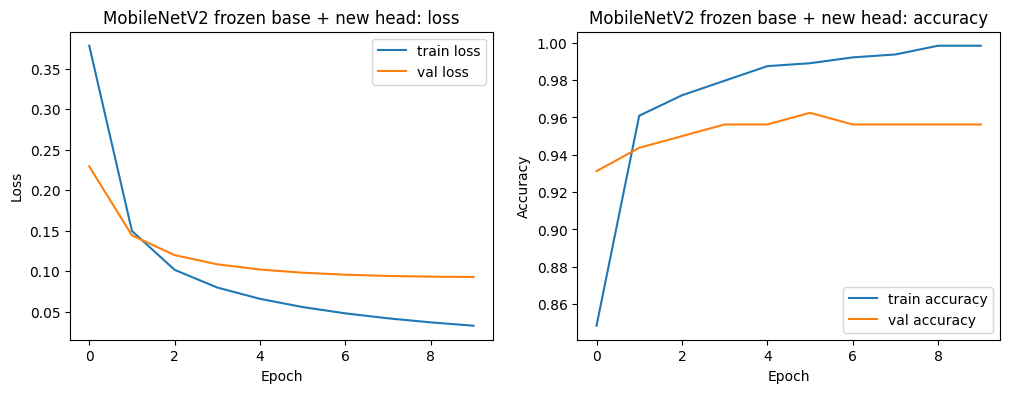

MobileNetV2 frozen base + Dense head
              precision    recall  f1-score   support

         Cat       1.00      0.97      0.98       100
         Dog       0.97      1.00      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



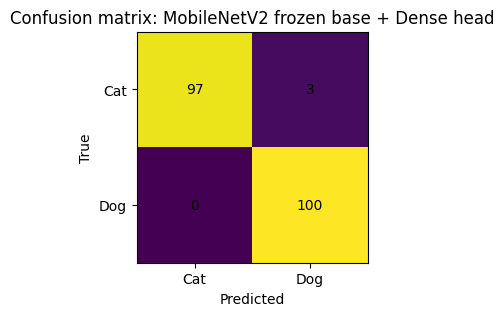

{'Модель': 'MobileNetV2 frozen base + Dense head',
 'Accuracy': 0.985,
 'Precision': 0.970873786407767,
 'Recall': 1.0,
 'F1': 0.9852216748768473,
 'Параметры': 2259265,
 'Время обучения, сек': 30.69380831718445,
 'Время предсказания test, сек': 16.241085290908813,
 'Комментарий': 'Предобученная MobileNetV2 заморожена, обучается только GAP + Dense'}

In [9]:
early_stop_head = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history_head, head_time = fit_with_time(
    transfer_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_head]
)

print(f'Время обучения головы MobileNetV2: {head_time:.2f} сек')
plot_history(history_head, 'MobileNetV2 frozen base + new head')

head_row = evaluate_binary_model(
    transfer_model,
    X_test,
    y_test,
    'MobileNetV2 frozen base + Dense head',
    head_time,
    'Предобученная MobileNetV2 заморожена, обучается только GAP + Dense'
)
head_row

## 5. MobileNetV2 fine-tuned: разморозка последних слоев

In [10]:
# Размораживаем только последние слои MobileNetV2
transfer_base.trainable = True

fine_tune_at = len(transfer_base.layers) - 30

for layer in transfer_base.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization лучше оставить замороженными при fine-tuning
for layer in transfer_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Всего слоев в MobileNetV2:', len(transfer_base.layers))
print('Разморожены последние слои начиная с индекса:', fine_tune_at)
print('Trainable parameters:', np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights]))

Всего слоев в MobileNetV2: 154
Разморожены последние слои начиная с индекса: 124
Trainable parameters: 1512001


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 293ms/step - accuracy: 0.9969 - loss: 0.0277 - val_accuracy: 0.9625 - val_loss: 0.0947
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9984 - loss: 0.0097 - val_accuracy: 0.9625 - val_loss: 0.1009
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.9688 - val_loss: 0.1056
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9688 - val_loss: 0.1108
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9688 - val_loss: 0.1141
Время fine-tuning MobileNetV2: 18.73 сек
Общее время обучения MobileNetV2 fine-tuned: 49.42 сек


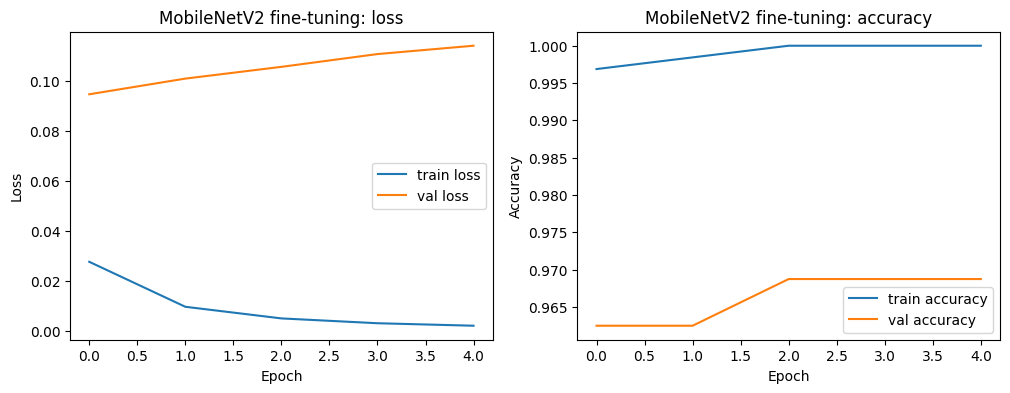

MobileNetV2 fine-tuned
              precision    recall  f1-score   support

         Cat       0.99      0.98      0.98       100
         Dog       0.98      0.99      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



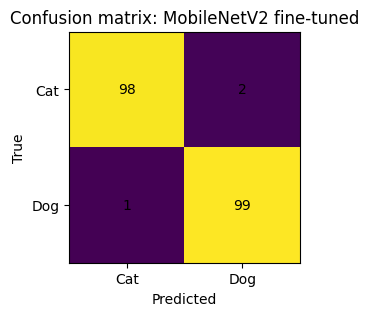

{'Модель': 'MobileNetV2 fine-tuned',
 'Accuracy': 0.985,
 'Precision': 0.9801980198019802,
 'Recall': 0.99,
 'F1': 0.9850746268656716,
 'Параметры': 2259265,
 'Время обучения, сек': 49.42337608337402,
 'Время предсказания test, сек': 9.418294906616211,
 'Комментарий': 'Предобученная MobileNetV2: новая голова + дообучение последних 30 слоев'}

In [11]:
early_stop_fine = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history_fine, fine_time = fit_with_time(
    transfer_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_fine]
)

full_mobilenet_time = head_time + fine_time

print(f'Время fine-tuning MobileNetV2: {fine_time:.2f} сек')
print(f'Общее время обучения MobileNetV2 fine-tuned: {full_mobilenet_time:.2f} сек')

plot_history(history_fine, 'MobileNetV2 fine-tuning')

fine_row = evaluate_binary_model(
    transfer_model,
    X_test,
    y_test,
    'MobileNetV2 fine-tuned',
    full_mobilenet_time,
    'Предобученная MobileNetV2: новая голова + дообучение последних 30 слоев'
)
fine_row

## 6. Сводная таблица результатов

In [12]:
final_results_df = pd.DataFrame(results)
final_results_df = final_results_df.sort_values(
    ['F1', 'Accuracy'],
    ascending=False
).reset_index(drop=True)

final_results_df

,Модель,Accuracy,Precision,Recall,F1,Параметры,"Время обучения, сек","Время предсказания test, сек",Комментарий
0,MobileNetV2 frozen base + Dense head,0.985,0.970874,1.00,0.985222,2259265,30.693808,16.241085,"Предобученная MobileNetV2 заморожена, обучаетс..."
1,MobileNetV2 fine-tuned,0.985,0.980198,0.99,0.985075,2259265,49.423376,9.418295,Предобученная MobileNetV2: новая голова + дооб...


## 7. Проверка своего изображения через кнопку загрузки

Saving 2267426463_1732709152_lh_average_step_4.jpg to 2267426463_1732709152_lh_average_step_4.jpg


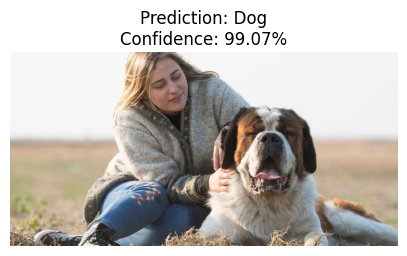

Файл: 2267426463_1732709152_lh_average_step_4.jpg
Вероятность Dog: 0.9907
Итог: Dog
Уверенность: 99.07%


In [17]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image(model, img_size=IMG_SIZE):
    uploaded = files.upload()

    for filename in uploaded.keys():

        img = Image.open(filename).convert('RGB')
        img_resized = img.resize((img_size, img_size))

        img_array = np.array(img_resized).astype('float32') / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_batch, verbose=0)[0][0]

        if pred >= 0.5:
            label = 'Dog'
            confidence = pred
        else:
            label = 'Cat'
            confidence = 1 - pred

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')

        plt.title(
            f'Prediction: {label}\n'
            f'Confidence: {confidence:.2%}'
        )

        plt.show()

        print(f'Файл: {filename}')
        print(f'Вероятность Dog: {pred:.4f}')
        print(f'Итог: {label}')
        print(f'Уверенность: {confidence:.2%}')

predict_uploaded_image(transfer_model)

## 8. Сохранение модели

In [18]:
transfer_model.save('mobilenetv2_fine_tuned_cats_dogs.keras')
print('Модель сохранена: mobilenetv2_fine_tuned_cats_dogs.keras')

Модель сохранена: mobilenetv2_fine_tuned_cats_dogs.keras
